In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def survive_exactly(death_chance, t):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
    if not isinstance(t, int):
        raise TypeError
    else:
        return (1-death_chance)**(t-1)*death_chance if t > 0 else 0

def p_lessequal(n_periods, death_chance):
    
    return pd.Series([sum(survive_exactly(death_chance, t) for t in range(0,t+1)) for t in range(0, n_periods+1)])

def p_test(n_periods, death_chance):

    return pd.Series(1-(1-death_chance)**t for t in range(0, n_periods+1))

In [33]:
start_pop = 12
birth_rate = 1
death_chance = 0.6
n_periods = 25

In [34]:
prob2 = p_test(n_periods, death_chance)
prob2

0     0.000000
1     0.600000
2     0.840000
3     0.936000
4     0.974400
5     0.989760
6     0.995904
7     0.998362
8     0.999345
9     0.999738
10    0.999895
11    0.999958
12    0.999983
13    0.999993
14    0.999997
15    0.999999
16    1.000000
17    1.000000
18    1.000000
19    1.000000
20    1.000000
21    1.000000
22    1.000000
23    1.000000
24    1.000000
25    1.000000
dtype: float64

In [35]:
prob = p_lessequal(n_periods, death_chance)
prob

0     0.000000
1     0.600000
2     0.840000
3     0.936000
4     0.974400
5     0.989760
6     0.995904
7     0.998362
8     0.999345
9     0.999738
10    0.999895
11    0.999958
12    0.999983
13    0.999993
14    0.999997
15    0.999999
16    1.000000
17    1.000000
18    1.000000
19    1.000000
20    1.000000
21    1.000000
22    1.000000
23    1.000000
24    1.000000
25    1.000000
dtype: float64

In [29]:
def recursive_pop(n_periods, death_chance, birth_rate, pop):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = [pop] #pop_0 is first item, the function returns
    for t in range(0,n_periods): #pop_t+1 for any t.
        pop = pop*(1-death_chance)+birth_rate
        p_function.append(pop)
    return p_function

def pop_equilib(birth_rate, death_chance):
    ''' Calculate the population equilibrium for population with constant birth rate
        and independent death chance'''

    return birth_rate/death_chance

In [30]:
pop = start_pop + prob*(pop_equilib(birth_rate, death_chance) - start_pop)
pop

0     12.000000
1     10.600000
2      9.480000
3      8.584000
4      7.867200
5      7.293760
6      6.835008
7      6.468006
8      6.174405
9      5.939524
10     5.751619
11     5.601295
12     5.481036
13     5.384829
14     5.307863
15     5.246291
16     5.197032
17     5.157626
18     5.126101
19     5.100881
20     5.080705
21     5.064564
22     5.051651
23     5.041321
24     5.033057
25     5.026445
dtype: float64

In [31]:
recursive_pop(n_periods, death_chance, birth_rate, pop)

[0     12.000000
 1     10.600000
 2      9.480000
 3      8.584000
 4      7.867200
 5      7.293760
 6      6.835008
 7      6.468006
 8      6.174405
 9      5.939524
 10     5.751619
 11     5.601295
 12     5.481036
 13     5.384829
 14     5.307863
 15     5.246291
 16     5.197032
 17     5.157626
 18     5.126101
 19     5.100881
 20     5.080705
 21     5.064564
 22     5.051651
 23     5.041321
 24     5.033057
 25     5.026445
 dtype: float64, 0     10.600000
 1      9.480000
 2      8.584000
 3      7.867200
 4      7.293760
 5      6.835008
 6      6.468006
 7      6.174405
 8      5.939524
 9      5.751619
 10     5.601295
 11     5.481036
 12     5.384829
 13     5.307863
 14     5.246291
 15     5.197032
 16     5.157626
 17     5.126101
 18     5.100881
 19     5.080705
 20     5.064564
 21     5.051651
 22     5.041321
 23     5.033057
 24     5.026445
 25     5.021156
 dtype: float64, 0     9.480000
 1     8.584000
 2     7.867200
 3     7.293760
 4     6.835008
 5  

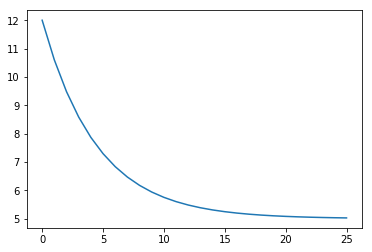

In [32]:
plt.plot(pop)